118 images × 39209 neurons
118 images × 39209 neurons


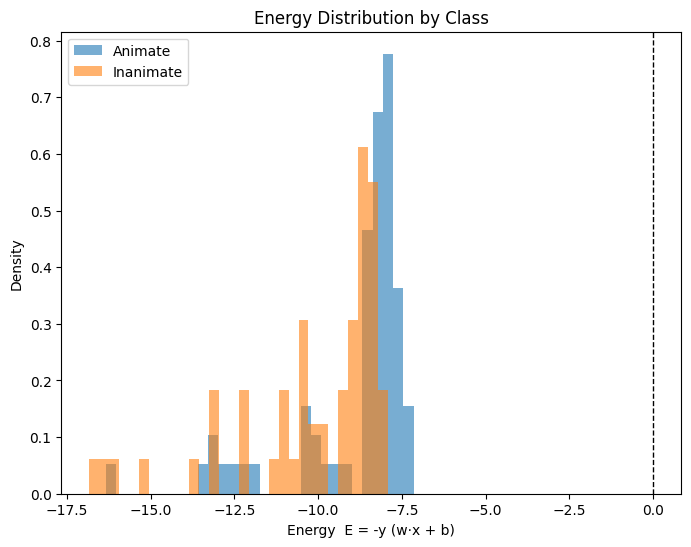

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

"""
Variance geometry diagnostics for large neural populations
Animate vs Inanimate decoding (ImageNet labels)

LOO logistic regression fields
PCA of field variability
Safe for ~20k–40k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)   # 1 = animate, 0 = inanimate

# ============================================================
# LOAD DATA (already in your script)
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# LABELS (you must define this properly)
# ============================================================

# Example:
# y = np.load("your_label_file.npy")   # shape (n_images,)
# y must be 0 (inanimate) or 1 (animate)

assert y.shape[0] == n_images

# ============================================================
# STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()
X = scaler.fit_transform(R)

# ============================================================
# FIT LOGISTIC REGRESSION
# ============================================================

clf = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=10000
)

clf.fit(X, y)

w = clf.coef_.ravel()
b = clf.intercept_[0]

# ============================================================
# COMPUTE MARGINS AND ENERGIES
# ============================================================

margins = X @ w + b                 # signed margin

# Convert labels to ±1 for physics-style energy
y_pm = 2*y - 1                      # 0-> -1, 1-> +1

energies = - y_pm * margins         # Boltzmann-style energy

# ============================================================
# SPLIT BY CLASS
# ============================================================

animate_mask     = (y == 1)
inanimate_mask   = (y == 0)

E_animate   = energies[animate_mask]
E_inanimate = energies[inanimate_mask]

m_animate   = margins[animate_mask]
m_inanimate = margins[inanimate_mask]

# ============================================================
# PLOT ENERGY DISTRIBUTIONS
# ============================================================

plt.figure(figsize=(8,6))

plt.hist(E_animate, bins=30, alpha=0.6, label='Animate', density=True)
plt.hist(E_inanimate, bins=30, alpha=0.6, label='Inanimate', density=True)

plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel("Energy  E = -y (w·x + b)")
plt.ylabel("Density")
plt.title("Energy Distribution by Class")
plt.legend()
plt.show()

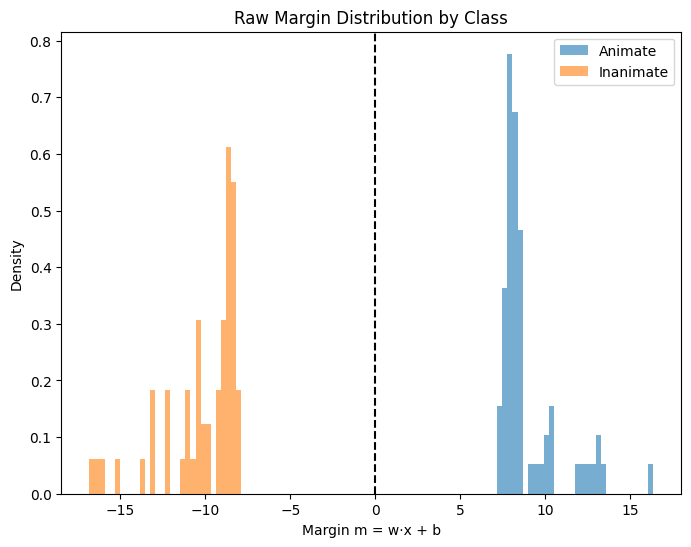

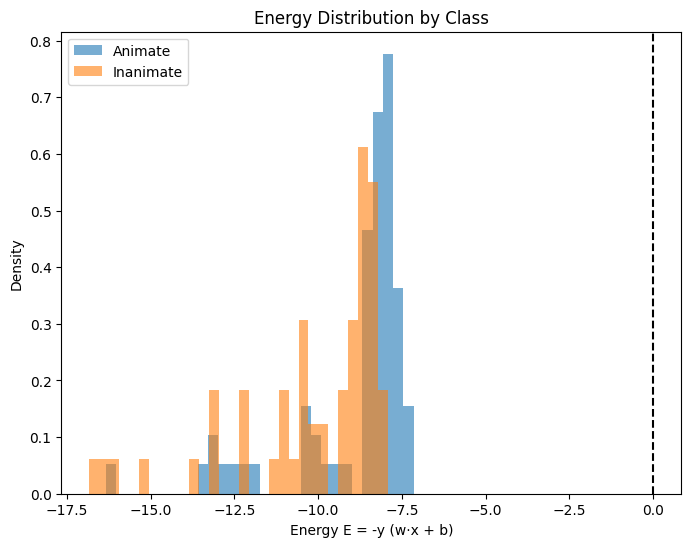

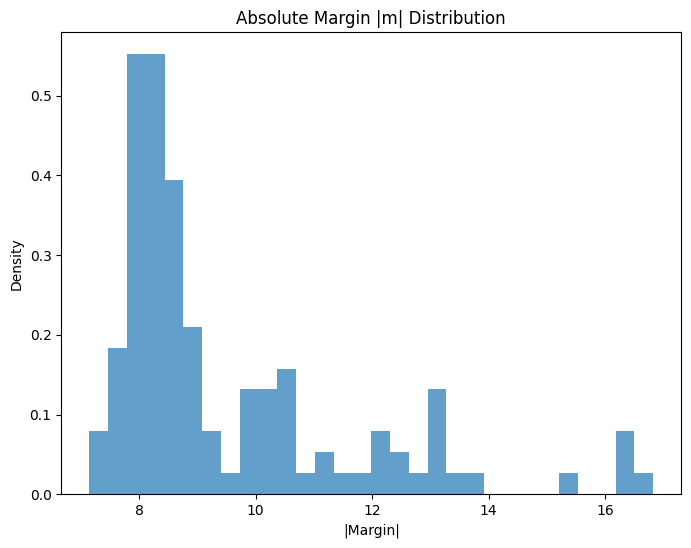

In [3]:
import matplotlib.pyplot as plt
import numpy as np

animate_mask   = (y == 1)
inanimate_mask = (y == 0)

m_animate   = margins[animate_mask]
m_inanimate = margins[inanimate_mask]

E_animate   = energies[animate_mask]
E_inanimate = energies[inanimate_mask]

abs_margins = np.abs(margins)

# --------------------------------------------------
# 1️⃣ RAW MARGINS
# --------------------------------------------------

plt.figure(figsize=(8,6))
plt.hist(m_animate, bins=30, alpha=0.6, label='Animate', density=True)
plt.hist(m_inanimate, bins=30, alpha=0.6, label='Inanimate', density=True)

plt.axvline(0, color='black', linestyle='--')
plt.title("Raw Margin Distribution by Class")
plt.xlabel("Margin m = w·x + b")
plt.ylabel("Density")
plt.legend()
plt.show()


# --------------------------------------------------
# 2️⃣ ENERGY DISTRIBUTION
# --------------------------------------------------

plt.figure(figsize=(8,6))
plt.hist(E_animate, bins=30, alpha=0.6, label='Animate', density=True)
plt.hist(E_inanimate, bins=30, alpha=0.6, label='Inanimate', density=True)

plt.axvline(0, color='black', linestyle='--')
plt.title("Energy Distribution by Class")
plt.xlabel("Energy E = -y (w·x + b)")
plt.ylabel("Density")
plt.legend()
plt.show()


# --------------------------------------------------
# 3️⃣ ABSOLUTE MARGIN (POLARIZATION STRENGTH)
# --------------------------------------------------

plt.figure(figsize=(8,6))
plt.hist(abs_margins, bins=30, alpha=0.7, density=True)

plt.title("Absolute Margin |m| Distribution")
plt.xlabel("|Margin|")
plt.ylabel("Density")
plt.show()

In [4]:
delta = 1.0   # adjust scale if needed
critical_fraction = np.mean(np.abs(margins) < delta)

print(f"Fraction of points with |margin| < {delta}: {critical_fraction:.3f}")

Fraction of points with |margin| < 1.0: 0.000



=== REAL LABELS ===
              w_norm: 0.483989
      min_abs_margin: 7.14827
     mean_abs_margin: 9.50272
  frac_critical_abs1: 0
         mean_energy: -9.50272
          max_energy: -7.14827
Running 500 shuffles on 24 cores...


[Parallel(n_jobs=24)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    2.3s
[Parallel(n_jobs=24)]: Done  13 tasks      | elapsed:    3.2s
[Parallel(n_jobs=24)]: Done  24 tasks      | elapsed:    4.1s
[Parallel(n_jobs=24)]: Done  37 tasks      | elapsed:    5.2s
[Parallel(n_jobs=24)]: Done  50 tasks      | elapsed:    6.0s
[Parallel(n_jobs=24)]: Done  65 tasks      | elapsed:    7.0s
[Parallel(n_jobs=24)]: Done  80 tasks      | elapsed:    8.0s
[Parallel(n_jobs=24)]: Done  97 tasks      | elapsed:    9.2s
[Parallel(n_jobs=24)]: Done 114 tasks      | elapsed:   10.1s
[Parallel(n_jobs=24)]: Done 133 tasks      | elapsed:   11.4s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:   12.6s
[Parallel(n_jobs=24)]: Done 173 tasks      | elapsed:   14.0s
[Parallel(n_jobs=24)]: Done 194 tasks      | elapsed:   15.2s
[Parallel(n_jobs=24)]: Done 217 tasks      | elapsed:   16.7s
[Parallel(n_jobs=24)]: Done 240 tasks      | elapsed:  


=== P-VALUES vs SHUFFLE NULL ===
    min_abs_margin (greater): 0.5449
   mean_abs_margin (greater): 0.1297
               w_norm (less): 0.01198
          mean_energy (less): 0.1297


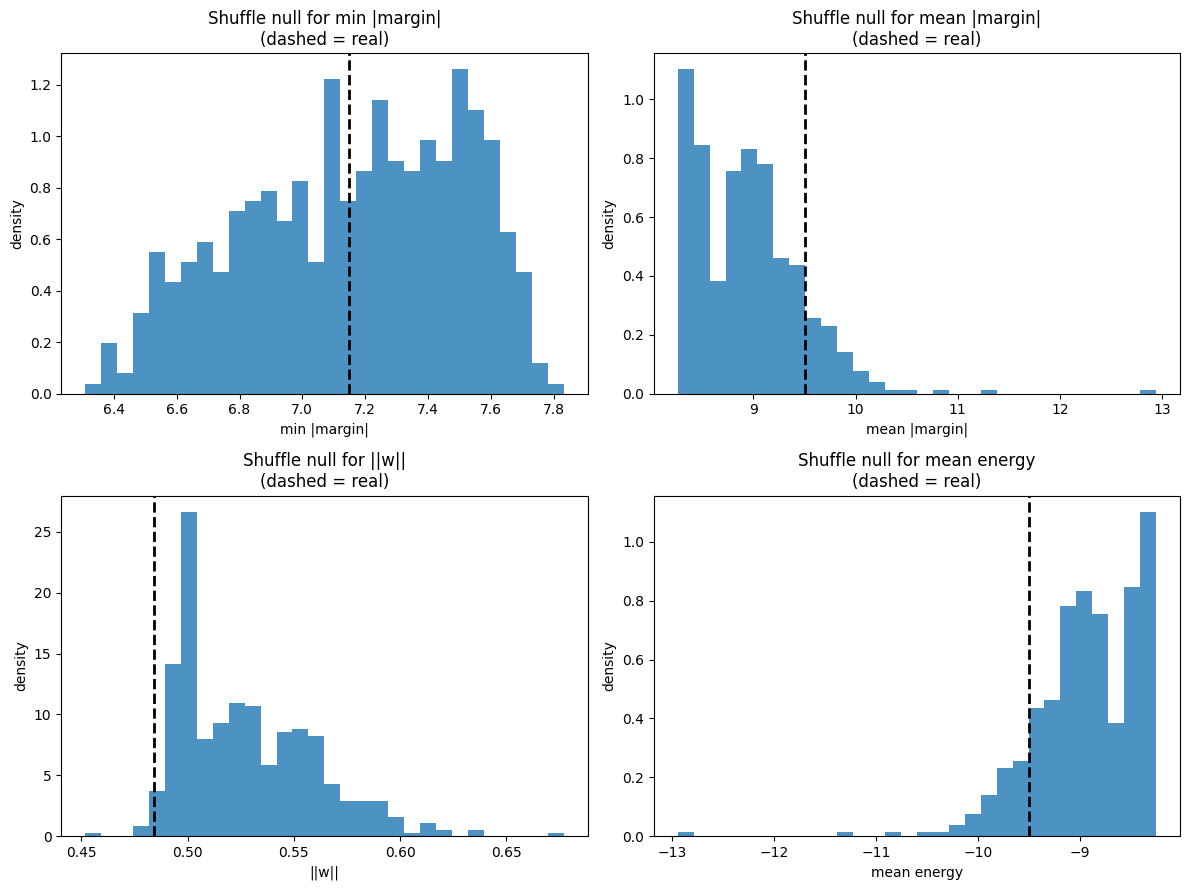

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

def fit_and_stats(X, y, C=1.0, seed=0):
    clf = LogisticRegression(
        penalty='l2',
        C=C,
        solver='lbfgs',
        max_iter=10000,
        random_state=seed
    )
    clf.fit(X, y)
    w = clf.coef_.ravel()
    b = clf.intercept_[0]

    margins = X @ w + b
    y_pm = 2*y - 1
    energies = -y_pm * margins

    stats = {
        "w_norm": float(np.linalg.norm(w)),
        "min_abs_margin": float(np.min(np.abs(margins))),
        "mean_abs_margin": float(np.mean(np.abs(margins))),
        "frac_critical_abs1": float(np.mean(np.abs(margins) < 1.0)),
        "mean_energy": float(np.mean(energies)),
        "max_energy": float(np.max(energies)),   # >0 would indicate misclassified points (under true labels)
    }
    return stats, margins, energies, w, b

# ============================================================
# 1) REAL LABELS
# ============================================================
C = 1.0
real_stats, real_margins, real_E, w_real, b_real = fit_and_stats(X, y, C=C, seed=0)

print("\n=== REAL LABELS ===")
for k, v in real_stats.items():
    print(f"{k:>20s}: {v:.6g}")

from joblib import Parallel, delayed
import multiprocessing

# ============================================================
# PARALLEL SHUFFLE NULL
# ============================================================

def shuffle_worker(seed):
    rng = np.random.default_rng(seed)
    y_shuff = rng.permutation(y)

    clf = LogisticRegression(
        penalty='l2',
        C=C,
        solver='lbfgs',
        max_iter=10000,
        random_state=seed
    )
    clf.fit(X, y_shuff)

    w = clf.coef_.ravel()
    b = clf.intercept_[0]

    margins = X @ w + b
    y_pm = 2*y_shuff - 1
    energies = -y_pm * margins

    return {
        "w_norm": np.linalg.norm(w),
        "min_abs_margin": np.min(np.abs(margins)),
        "mean_abs_margin": np.mean(np.abs(margins)),
        "frac_critical_abs1": np.mean(np.abs(margins) < 1.0),
        "mean_energy": np.mean(energies),
    }

# --------------------------------------------------
# RUN PARALLEL
# --------------------------------------------------

B = 500
n_jobs = multiprocessing.cpu_count()

print(f"Running {B} shuffles on {n_jobs} cores...")

results = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(shuffle_worker)(seed)
    for seed in range(B)
)

# Convert list of dicts → dict of arrays
null = {k: np.array([res[k] for res in results])
        for k in results[0].keys()}

# ============================================================
# 3) ONE-SIDED P-VALUES (choose direction per stat)
# ============================================================
# For "signal is real" you might expect: larger margins, lower ||w||, more negative mean_energy
def pval_greater(real, arr):  # P(null >= real)
    return (np.sum(arr >= real) + 1) / (len(arr) + 1)

def pval_less(real, arr):     # P(null <= real)
    return (np.sum(arr <= real) + 1) / (len(arr) + 1)

pvals = {}
pvals["min_abs_margin (greater)"]  = pval_greater(real_stats["min_abs_margin"], null["min_abs_margin"])
pvals["mean_abs_margin (greater)"] = pval_greater(real_stats["mean_abs_margin"], null["mean_abs_margin"])
pvals["w_norm (less)"]             = pval_less(real_stats["w_norm"], null["w_norm"])
pvals["mean_energy (less)"]        = pval_less(real_stats["mean_energy"], null["mean_energy"])

print("\n=== P-VALUES vs SHUFFLE NULL ===")
for k, v in pvals.items():
    print(f"{k:>28s}: {v:.4g}")

# ============================================================
# 4) PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

plot_specs = [
    ("min_abs_margin", "min |margin|", real_stats["min_abs_margin"]),
    ("mean_abs_margin", "mean |margin|", real_stats["mean_abs_margin"]),
    ("w_norm", "||w||", real_stats["w_norm"]),
    ("mean_energy", "mean energy", real_stats["mean_energy"]),
]

for ax, (key, label, real_val) in zip(axes, plot_specs):
    ax.hist(null[key], bins=30, density=True, alpha=0.8)
    ax.axvline(real_val, color="black", linestyle="--", linewidth=2)
    ax.set_title(f"Shuffle null for {label}\n(dashed = real)")
    ax.set_xlabel(label)
    ax.set_ylabel("density")

plt.tight_layout()
plt.show()


=== REAL (GEOMETRIC) ===
                  w_norm: 0.483989
     min_abs_geom_margin: 14.7695
    mean_abs_geom_margin: 19.6342
      frac_critical_geom: 0
  min_signed_geom_margin: 14.7695
 mean_signed_geom_margin: 19.6342

Running 500 shuffles on 24 cores...


[Parallel(n_jobs=24)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.7s
[Parallel(n_jobs=24)]: Done  13 tasks      | elapsed:    1.6s
[Parallel(n_jobs=24)]: Done  24 tasks      | elapsed:    2.3s
[Parallel(n_jobs=24)]: Done  37 tasks      | elapsed:    3.3s
[Parallel(n_jobs=24)]: Done  50 tasks      | elapsed:    4.2s
[Parallel(n_jobs=24)]: Done  65 tasks      | elapsed:    5.2s
[Parallel(n_jobs=24)]: Done  80 tasks      | elapsed:    6.0s
[Parallel(n_jobs=24)]: Done  97 tasks      | elapsed:    7.1s
[Parallel(n_jobs=24)]: Done 114 tasks      | elapsed:    8.0s
[Parallel(n_jobs=24)]: Done 133 tasks      | elapsed:    9.4s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:   10.6s
[Parallel(n_jobs=24)]: Done 173 tasks      | elapsed:   12.0s
[Parallel(n_jobs=24)]: Done 194 tasks      | elapsed:   13.3s
[Parallel(n_jobs=24)]: Done 217 tasks      | elapsed:   14.7s
[Parallel(n_jobs=24)]: Done 240 tasks      | elapsed:  


=== P-VALUES vs SHUFFLE NULL (GEOMETRIC) ===
   mean_abs_geom_margin (greater): 0.001996
   min_abs_geom_margin  (greater): 0.2635
      frac_critical_geom   (less): 1
mean_signed_geom_margin (greater): 0.001996
                    w_norm (less): 0.01198


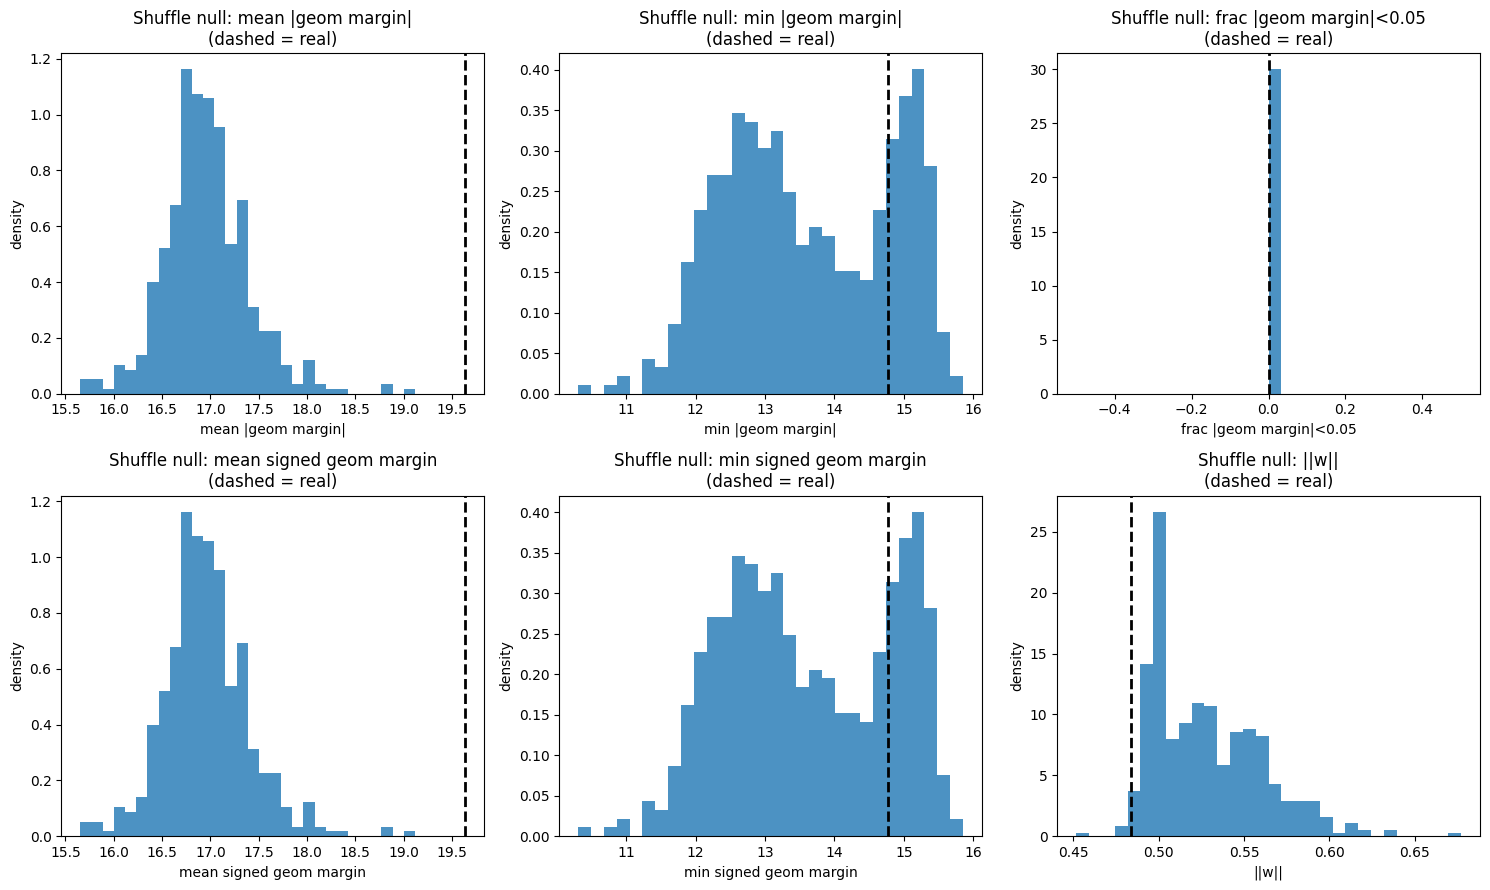

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from joblib import Parallel, delayed
import multiprocessing

def fit_geom_stats(X, y, C=1.0, seed=0, delta=0.05):
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=10000,
        random_state=seed
    )
    clf.fit(X, y)
    w = clf.coef_.ravel()
    b = clf.intercept_[0]
    wnorm = np.linalg.norm(w) + 1e-12

    m = X @ w + b  # raw margins
    g = m / wnorm  # geometric margins

    y_pm = 2*y - 1
    g_signed = y_pm * g  # positive = correct side, negative = wrong side

    stats = {
        "w_norm": float(wnorm),
        "min_abs_geom_margin": float(np.min(np.abs(g))),
        "mean_abs_geom_margin": float(np.mean(np.abs(g))),
        "frac_critical_geom": float(np.mean(np.abs(g) < delta)),
        "min_signed_geom_margin": float(np.min(g_signed)),
        "mean_signed_geom_margin": float(np.mean(g_signed)),
    }
    return stats

def pval_greater(real, arr):  # P(null >= real)
    return (np.sum(arr >= real) + 1) / (len(arr) + 1)

def pval_less(real, arr):     # P(null <= real)
    return (np.sum(arr <= real) + 1) / (len(arr) + 1)

# -----------------------------
# CONFIG
# -----------------------------
C = 1.0
B = 500
delta = 0.05  # geometric "critical band" width
n_jobs = multiprocessing.cpu_count()

# -----------------------------
# REAL
# -----------------------------
real_stats = fit_geom_stats(X, y, C=C, seed=0, delta=delta)

print("\n=== REAL (GEOMETRIC) ===")
for k, v in real_stats.items():
    print(f"{k:>24s}: {v:.6g}")

# -----------------------------
# NULL (PARALLEL SHUFFLES)
# -----------------------------
def worker(seed):
    rng = np.random.default_rng(seed)
    y_shuff = rng.permutation(y)
    return fit_geom_stats(X, y_shuff, C=C, seed=seed, delta=delta)

print(f"\nRunning {B} shuffles on {n_jobs} cores...")
res = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(worker)(seed) for seed in range(B)
)

null = {k: np.array([r[k] for r in res]) for k in res[0].keys()}

# -----------------------------
# P-VALUES (directions)
# -----------------------------
pvals = {
    "mean_abs_geom_margin (greater)": pval_greater(real_stats["mean_abs_geom_margin"], null["mean_abs_geom_margin"]),
    "min_abs_geom_margin  (greater)": pval_greater(real_stats["min_abs_geom_margin"],  null["min_abs_geom_margin"]),
    "frac_critical_geom   (less)"   : pval_less(real_stats["frac_critical_geom"],     null["frac_critical_geom"]),
    "mean_signed_geom_margin (greater)": pval_greater(real_stats["mean_signed_geom_margin"], null["mean_signed_geom_margin"]),
    "w_norm (less)" : pval_less(real_stats["w_norm"], null["w_norm"]),
}

print("\n=== P-VALUES vs SHUFFLE NULL (GEOMETRIC) ===")
for k, v in pvals.items():
    print(f"{k:>33s}: {v:.4g}")

# -----------------------------
# PLOTS
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

specs = [
    ("mean_abs_geom_margin", "mean |geom margin|", real_stats["mean_abs_geom_margin"]),
    ("min_abs_geom_margin",  "min |geom margin|",  real_stats["min_abs_geom_margin"]),
    ("frac_critical_geom",   f"frac |geom margin|<{delta}", real_stats["frac_critical_geom"]),
    ("mean_signed_geom_margin", "mean signed geom margin", real_stats["mean_signed_geom_margin"]),
    ("min_signed_geom_margin",  "min signed geom margin",  real_stats["min_signed_geom_margin"]),
    ("w_norm", "||w||", real_stats["w_norm"]),
]

for ax, (key, label, real_val) in zip(axes, specs):
    ax.hist(null[key], bins=30, density=True, alpha=0.8)
    ax.axvline(real_val, color="black", linestyle="--", linewidth=2)
    ax.set_title(f"Shuffle null: {label}\n(dashed = real)")
    ax.set_xlabel(label)
    ax.set_ylabel("density")

plt.tight_layout()
plt.show()


=== EFFECT SIZE ===
Cohen's d: 9.2859
SNR: 6.5661
KL(Animate || Inanimate): nan
KL(Inanimate || Animate): nan


/home/maria/global_venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


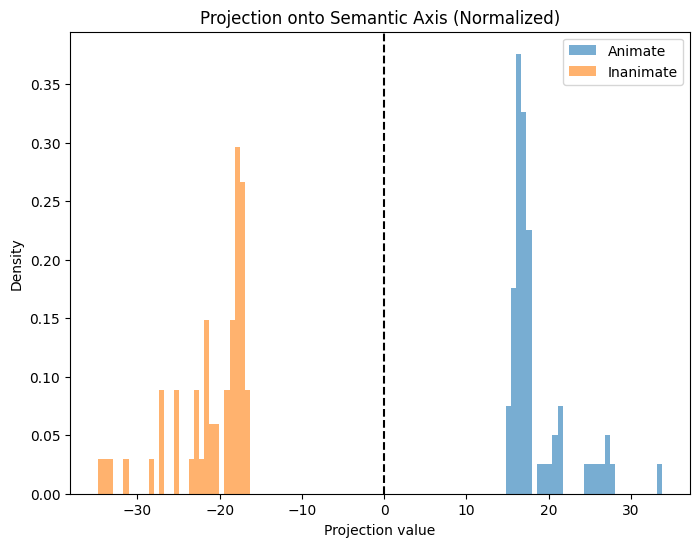

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# --------------------------------------------------
# 1️⃣ 1D PROJECTION ONTO NORMALIZED AXIS
# --------------------------------------------------

u = w_real / (np.linalg.norm(w_real) + 1e-12)
z = X @ u

z_animate   = z[y == 1]
z_inanimate = z[y == 0]

# --------------------------------------------------
# 2️⃣ COHEN'S D (Effect Size)
# --------------------------------------------------

mean_a = np.mean(z_animate)
mean_i = np.mean(z_inanimate)

std_a = np.std(z_animate, ddof=1)
std_i = np.std(z_inanimate, ddof=1)

pooled_std = np.sqrt((std_a**2 + std_i**2) / 2)

cohens_d = (mean_a - mean_i) / pooled_std

print("\n=== EFFECT SIZE ===")
print(f"Cohen's d: {cohens_d:.4f}")

# --------------------------------------------------
# 3️⃣ SIGNAL-TO-NOISE RATIO
# --------------------------------------------------

snr = np.abs(mean_a - mean_i) / np.sqrt(std_a**2 + std_i**2)
print(f"SNR: {snr:.4f}")

# --------------------------------------------------
# 4️⃣ KL DIVERGENCE (Histogram Estimate)
# --------------------------------------------------

bins = 30
hist_a, edges = np.histogram(z_animate, bins=bins, density=True)
hist_i, _     = np.histogram(z_inanimate, bins=edges, density=True)

# Add small constant to avoid log(0)
eps = 1e-8
hist_a += eps
hist_i += eps

kl_ai = entropy(hist_a, hist_i)
kl_ia = entropy(hist_i, hist_a)

print(f"KL(Animate || Inanimate): {kl_ai:.4f}")
print(f"KL(Inanimate || Animate): {kl_ia:.4f}")

# --------------------------------------------------
# 5️⃣ VISUALIZATION
# --------------------------------------------------

plt.figure(figsize=(8,6))
plt.hist(z_animate, bins=30, alpha=0.6, label="Animate", density=True)
plt.hist(z_inanimate, bins=30, alpha=0.6, label="Inanimate", density=True)

plt.axvline(0, color='black', linestyle='--')
plt.title("Projection onto Semantic Axis (Normalized)")
plt.xlabel("Projection value")
plt.ylabel("Density")
plt.legend()
plt.show()


=== AXIS SPARSITY SUMMARY (L1 mass) ===
Neurons to reach 50% of |u| mass: 9563 / 39209
Neurons to reach 90% of |u| mass: 25504 / 39209
Neurons to reach 95% of |u| mass: 29484 / 39209
Neurons to reach 99% of |u| mass: 34846 / 39209


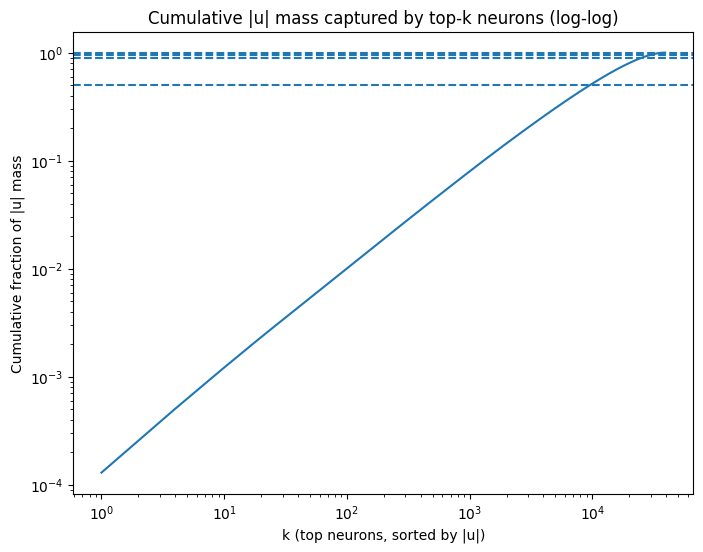


Participation ratio (effective #neurons): 13798.59 / 39209
Gini(|u|): 0.4067


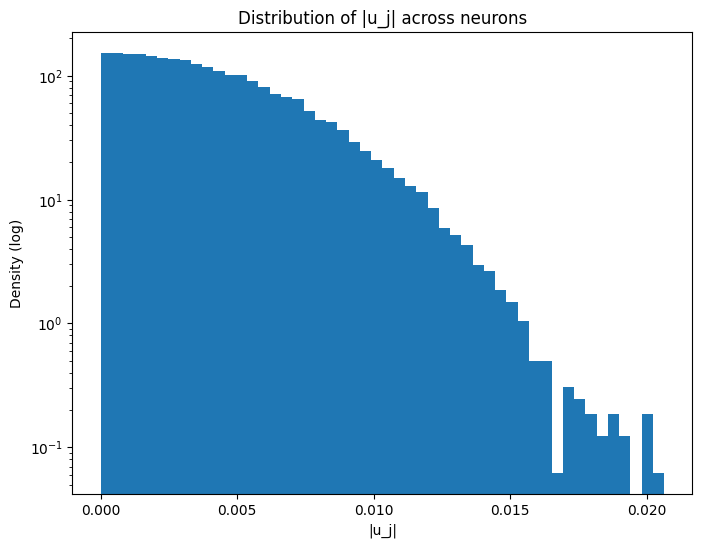


Top 30 |u_j| values:
[0.02063871 0.02011164 0.02000707 0.01994302 0.01909893 0.01906083
 0.01895163 0.01890569 0.01868695 0.01835644 0.01818298 0.01803967
 0.01781722 0.01780807 0.01764515 0.01763367 0.01752492 0.01744727
 0.01710464 0.0170264  0.01702525 0.01701582 0.01692855 0.01683906
 0.01648642 0.01648006 0.0164449  0.01642177 0.01623964 0.01621442]

Top 30 neuron indices:
[25810 18738 34429 36590 32772 31183  2411 19815 23100 25627 38542 17446
   691 36098 18310 12698 12029 12676 34857 36806  7680 11412 23082 11690
 15959 17228 16620 25129 23787  4572]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# u is normalized axis (same shape as neurons)
# If you already have w_real:
u = w_real / (np.linalg.norm(w_real) + 1e-12)

abs_u = np.abs(u)

# ------------------------------------------------------------
# 1) TOP-K MASS FRACTION CURVE
#   use L1 mass (abs weights) as "contribution mass"
# ------------------------------------------------------------
order = np.argsort(abs_u)[::-1]            # descending
abs_sorted = abs_u[order]
cum_mass = np.cumsum(abs_sorted)
total_mass = cum_mass[-1]
cum_frac = cum_mass / (total_mass + 1e-12)

# Find k for various targets
targets = [0.5, 0.9, 0.95, 0.99]
k_at = {}
for t in targets:
    k_at[t] = int(np.searchsorted(cum_frac, t) + 1)

print("\n=== AXIS SPARSITY SUMMARY (L1 mass) ===")
for t in targets:
    print(f"Neurons to reach {int(t*100)}% of |u| mass: {k_at[t]} / {len(u)}")

# Plot curve
plt.figure(figsize=(8,6))
plt.plot(np.arange(1, len(u)+1), cum_frac)
plt.xscale("log")
plt.yscale("log")
plt.axhline(0.5, linestyle="--")
plt.axhline(0.9, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.axhline(0.99, linestyle="--")
plt.title("Cumulative |u| mass captured by top-k neurons (log-log)")
plt.xlabel("k (top neurons, sorted by |u|)")
plt.ylabel("Cumulative fraction of |u| mass")
plt.show()

# ------------------------------------------------------------
# 2) PARTICIPATION RATIO (effective dimensionality / support size)
#   For a unit vector, PR is between 1 and N:
#   PR = 1 / sum(u_j^4)
#   (if perfectly uniform u_j ~ 1/sqrt(N) => PR ~ N)
# ------------------------------------------------------------
pr = 1.0 / np.sum(u**4)
print(f"\nParticipation ratio (effective #neurons): {pr:.2f} / {len(u)}")

# ------------------------------------------------------------
# 3) GINI COEFFICIENT of |u| (0=uniform, 1=extremely sparse)
# ------------------------------------------------------------
def gini(x):
    x = np.asarray(x)
    x = x[x >= 0]
    if np.allclose(x.sum(), 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n+1)
    return (np.sum((2*idx - n - 1) * x)) / (n * np.sum(x))

g = gini(abs_u)
print(f"Gini(|u|): {g:.4f}")

# ------------------------------------------------------------
# 4) QUICK VISUALS: weight histogram + top weights
# ------------------------------------------------------------
plt.figure(figsize=(8,6))
plt.hist(abs_u, bins=50, density=True)
plt.yscale("log")
plt.title("Distribution of |u_j| across neurons")
plt.xlabel("|u_j|")
plt.ylabel("Density (log)")
plt.show()

topK = 30
print(f"\nTop {topK} |u_j| values:")
print(abs_sorted[:topK])

# Optional: indices of top neurons in original ordering
top_idx = order[:topK]
print(f"\nTop {topK} neuron indices:")
print(top_idx)